In [1]:
# ============================================================
# PART 4: ROBUSTNESS TEST
# ============================================================
import os
import gc
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
)
from peft import PeftModel
from sklearn.metrics import f1_score, accuracy_score, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

os.makedirs("../results/analysis", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

Device: cuda
GPU: NVIDIA GeForce RTX 2050


In [2]:
# ============================================================
# Load Trained XLM-R + LoRA (B1)
# ============================================================
MODEL_DIR = "../results/models/lora_b1_final"

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
base_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=3,
)
model = PeftModel.from_pretrained(base_model, MODEL_DIR)
model.eval()
model.to(device)

print(f"✅ Model loaded from: {MODEL_DIR}")
print(f"Type: {type(model).__name__}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded from: ../results/models/lora_b1_final
Type: PeftModelForSequenceClassification


In [3]:
# ============================================================
# Load Test Data (B1: URL Holdout)
# ============================================================
test_df = pd.read_csv("../data/processed/test_hard2.csv")

labels = ['normal', 'promo', 'smish']
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

print(f"Test size: {len(test_df)}")
print(f"Label distribution:\n{test_df['label'].value_counts()}")

Test size: 2107
Label distribution:
label
smish     1267
normal     498
promo      342
Name: count, dtype: int64


In [4]:
# ============================================================
# Perturbation Functions
# ============================================================
def perturb_typo(text, prob=0.05):
    """Random character swap within words"""
    text = str(text)
    chars = list(text)
    n = len(chars)
    for i in range(1, n-1):
        if random.random() < prob and chars[i].isalpha() and chars[i+1].isalpha():
            chars[i], chars[i+1] = chars[i+1], chars[i]
    return ''.join(chars)


def perturb_space(text, prob=0.03):
    """Insert extra spaces randomly"""
    text = str(text)
    chars = list(text)
    n = len(chars)
    for i in range(n):
        if random.random() < prob and chars[i] == ' ':
            chars[i] = '  '  # double space
    return ''.join(chars)


def perturb_case(text, prob=0.1):
    """Random case flip for English chars"""
    text = str(text)
    return ''.join(
        c.upper() if c.isascii() and c.isalpha() and random.random() < prob
        else c
        for c in text
    )


def perturb_mixed(text, seed=None):
    """Apply multiple perturbations"""
    if seed is not None:
        random.seed(seed)
    text = perturb_typo(text, prob=0.05)
    text = perturb_space(text, prob=0.03)
    text = perturb_case(text, prob=0.1)
    return text


# Test on sample
sample = test_df['text_clean'].iloc[0]
print("Original  :", sample[:150])
print("Typo      :", perturb_typo(sample)[:150])
print("Mixed     :", perturb_mixed(sample, seed=42)[:150])

Original  : আপনি ৩ vori gold জিতেছেন! Claim করুন: [PHONE]
Typo      : আপনি ৩ vori glod জিতেছেন! Claim করুন: [PHOEN]
Mixed     : আপনি ৩ VOri glOd জিতেছেন! ClaiM করুন: [PHOEN]


In [5]:
# ============================================================
# Prediction Helper
# ============================================================
class SMSDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding="max_length", max_length=self.max_len,
            return_tensors=None,
        )
        return enc


def predict(texts, model, tokenizer, batch_size=32):
    ds = SMSDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size,
                         collate_fn=DataCollatorWithPadding(tokenizer))
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_preds)


def evaluate_predictions(y_true, y_pred, label):
    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    smish_idx = label2id['smish']
    smish_mask = y_true == smish_idx
    smish_recall = (y_pred[smish_mask] == smish_idx).mean()
    return {
        "condition": label,
        "macro_f1": float(f1),
        "accuracy": float(acc),
        "smish_recall": float(smish_recall),
    }

In [6]:
# ============================================================
# Clean Baseline
# ============================================================
print("=" * 60)
print("CLEAN TEST (no perturbation)")
print("=" * 60)

y_true = np.array([label2id[l] for l in test_df['label']])

# Clean predictions
y_pred_clean = predict(test_df['text_clean'].astype(str).tolist(), model, tokenizer)
result_clean = evaluate_predictions(y_true, y_pred_clean, "Clean")

print(f"Macro F1     : {result_clean['macro_f1']:.4f}")
print(f"Accuracy     : {result_clean['accuracy']:.4f}")
print(f"Smish Recall : {result_clean['smish_recall']:.4f}")

CLEAN TEST (no perturbation)
Macro F1     : 0.7463
Accuracy     : 0.7451
Smish Recall : 0.5888


In [7]:
# ============================================================
# Robustness Test — All Perturbations
# ============================================================
all_results = [result_clean]

# --- 1. Typo (5% char swap) ---
print("\n" + "=" * 60)
print("PERTURBATION 1: TYPO (5% char swap)")
print("=" * 60)
random.seed(SEED)
texts_typo = [perturb_typo(t) for t in test_df['text_clean'].astype(str)]
y_pred_typo = predict(texts_typo, model, tokenizer)
result_typo = evaluate_predictions(y_true, y_pred_typo, "Typo (5%)")
all_results.append(result_typo)
print(f"Macro F1     : {result_typo['macro_f1']:.4f}")
print(f"Smish Recall : {result_typo['smish_recall']:.4f}")

# --- 2. Extra Spaces ---
print("\n" + "=" * 60)
print("PERTURBATION 2: EXTRA SPACES")
print("=" * 60)
random.seed(SEED)
texts_space = [perturb_space(t) for t in test_df['text_clean'].astype(str)]
y_pred_space = predict(texts_space, model, tokenizer)
result_space = evaluate_predictions(y_true, y_pred_space, "Extra Spaces")
all_results.append(result_space)
print(f"Macro F1     : {result_space['macro_f1']:.4f}")
print(f"Smish Recall : {result_space['smish_recall']:.4f}")

# --- 3. Case Flip ---
print("\n" + "=" * 60)
print("PERTURBATION 3: CASE FLIP")
print("=" * 60)
random.seed(SEED)
texts_case = [perturb_case(t) for t in test_df['text_clean'].astype(str)]
y_pred_case = predict(texts_case, model, tokenizer)
result_case = evaluate_predictions(y_true, y_pred_case, "Case Flip")
all_results.append(result_case)
print(f"Macro F1     : {result_case['macro_f1']:.4f}")
print(f"Smish Recall : {result_case['smish_recall']:.4f}")

# --- 4. Mixed (All combined) ---
print("\n" + "=" * 60)
print("PERTURBATION 4: MIXED (all combined)")
print("=" * 60)
texts_mixed = [perturb_mixed(t, seed=SEED+i) for i, t in enumerate(test_df['text_clean'].astype(str))]
y_pred_mixed = predict(texts_mixed, model, tokenizer)
result_mixed = evaluate_predictions(y_true, y_pred_mixed, "Mixed")
all_results.append(result_mixed)
print(f"Macro F1     : {result_mixed['macro_f1']:.4f}")
print(f"Smish Recall : {result_mixed['smish_recall']:.4f}")


PERTURBATION 1: TYPO (5% char swap)
Macro F1     : 0.7330
Smish Recall : 0.5675

PERTURBATION 2: EXTRA SPACES
Macro F1     : 0.7463
Smish Recall : 0.5888

PERTURBATION 3: CASE FLIP
Macro F1     : 0.7163
Smish Recall : 0.5438

PERTURBATION 4: MIXED (all combined)
Macro F1     : 0.6990
Smish Recall : 0.5146


In [8]:
# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "=" * 80)
print("ROBUSTNESS TEST SUMMARY")
print("=" * 80)
print(f"{'Condition':<20s} | {'Macro F1':>10s} | {'Accuracy':>10s} | {'Smish Recall':>14s} | {'Δ F1':>10s}")
print("-" * 80)

baseline_f1 = all_results[0]['macro_f1']
for r in all_results:
    delta = r['macro_f1'] - baseline_f1
    print(f"{r['condition']:<20s} | {r['macro_f1']:>10.4f} | "
          f"{r['accuracy']:>10.4f} | {r['smish_recall']:>14.4f} | {delta:>+10.4f}")

print("=" * 80)

# Save
robustness_results = {
    "test_split": "B1_URL_Holdout",
    "model": "XLM-R + LoRA r=16",
    "results": all_results,
}
with open("../results/analysis/robustness_results.json", "w") as f:
    json.dump(robustness_results, f, indent=2)

print("\n✅ Saved: ../results/analysis/robustness_results.json")


ROBUSTNESS TEST SUMMARY
Condition            |   Macro F1 |   Accuracy |   Smish Recall |       Δ F1
--------------------------------------------------------------------------------
Clean                |     0.7463 |     0.7451 |         0.5888 |    +0.0000
Typo (5%)            |     0.7330 |     0.7328 |         0.5675 |    -0.0134
Extra Spaces         |     0.7463 |     0.7451 |         0.5888 |    +0.0000
Case Flip            |     0.7163 |     0.7171 |         0.5438 |    -0.0300
Mixed                |     0.6990 |     0.6986 |         0.5146 |    -0.0473

✅ Saved: ../results/analysis/robustness_results.json


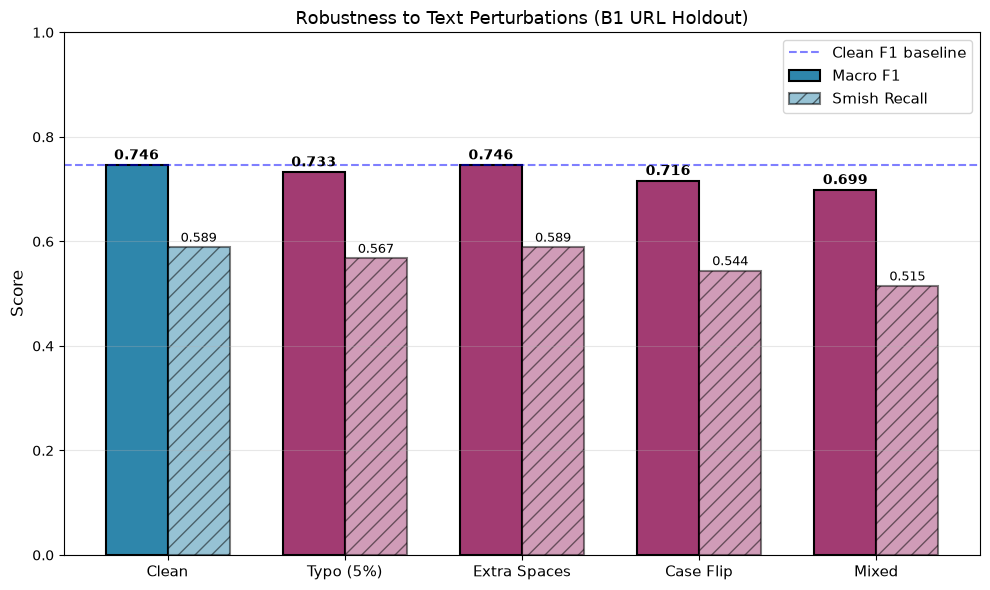

✅ Saved: ../results/figures/robustness_test.png


In [9]:
# ============================================================
# ROBUSTNESS PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

conditions = [r['condition'] for r in all_results]
f1_scores = [r['macro_f1'] for r in all_results]
smish_recalls = [r['smish_recall'] for r in all_results]

x = np.arange(len(conditions))
width = 0.35

colors = ['#2E86AB' if c == 'Clean' else '#A23B72' for c in conditions]

bars1 = ax.bar(x - width/2, f1_scores, width,
                label='Macro F1', color=colors, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, smish_recalls, width,
                label='Smish Recall', color=colors, alpha=0.5,
                edgecolor='black', linewidth=1.5, hatch='//')

# Value labels
for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points",
                ha='center', fontsize=10, fontweight='bold')

for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points",
                ha='center', fontsize=9)

# Clean baseline reference
ax.axhline(f1_scores[0], color='blue', linestyle='--',
            alpha=0.5, linewidth=1.5, label='Clean F1 baseline')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Robustness to Text Perturbations (B1 URL Holdout)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig("../results/figures/robustness_test.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ../results/figures/robustness_test.png")